/home/my_node2vec_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Wczytywanie zbioru CIFAR-10...

ROZPOCZĘCIE PRZETWARZANIA DLA METODY: PIXEL
Rozpoczęto ekstrakcję cech (100 obrazów)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  82 out of 100 | elapsed:  3.2min remaining:   42.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.


Średni czas grafu: 0.0723 s | Czas N2V: 39.7467 s

ROZPOCZĘCIE PRZETWARZANIA DLA METODY: PATCH
Rozpoczęto ekstrakcję cech (100 obrazów)...


[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done  82 out of 100 | elapsed:   26.6s remaining:    5.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   30.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.


Średni czas grafu: 0.0231 s | Czas N2V: 5.5062 s

ROZPOCZĘCIE PRZETWARZANIA DLA METODY: SLIC
Rozpoczęto ekstrakcję cech (100 obrazów)...


[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  82 out of 100 | elapsed:    3.4s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.4s finished


Średni czas grafu: 0.0078 s | Czas N2V: 0.7261 s

FAZA PREDYKCYJNA - ZBIORCZE PORÓWNANIE PO POPRAWKACH

--- Ocena predykcyjna (5-Fold CV) dla: Node2Vec - PIXEL ---
[LogReg] Accuracy: 0.200 | F1-Macro: 0.176
[RandomForest] Accuracy: 0.150 | F1-Macro: 0.088
[SVM (RBF)] Accuracy: 0.190 | F1-Macro: 0.086

--- Ocena predykcyjna (5-Fold CV) dla: Node2Vec - PATCH ---
[LogReg] Accuracy: 0.090 | F1-Macro: 0.055
[RandomForest] Accuracy: 0.070 | F1-Macro: 0.051
[SVM (RBF)] Accuracy: 0.150 | F1-Macro: 0.026

--- Ocena predykcyjna (5-Fold CV) dla: Node2Vec - SLIC ---
[LogReg] Accuracy: 0.150 | F1-Macro: 0.081
[RandomForest] Accuracy: 0.100 | F1-Macro: 0.076
[SVM (RBF)] Accuracy: 0.150 | F1-Macro: 0.026

--- Ocena predykcyjna (5-Fold CV) dla: Baseline (RGB Mean) ---
[LogReg] Accuracy: 0.160 | F1-Macro: 0.051
[RandomForest] Accuracy: 0.160 | F1-Macro: 0.122
[SVM (RBF)] Accuracy: 0.130 | F1-Macro: 0.057

--- Ocena predykcyjna (5-Fold CV) dla: Baseline (HOG) ---
[LogReg] Accuracy: 0.340 | F1-Macro: 0.2

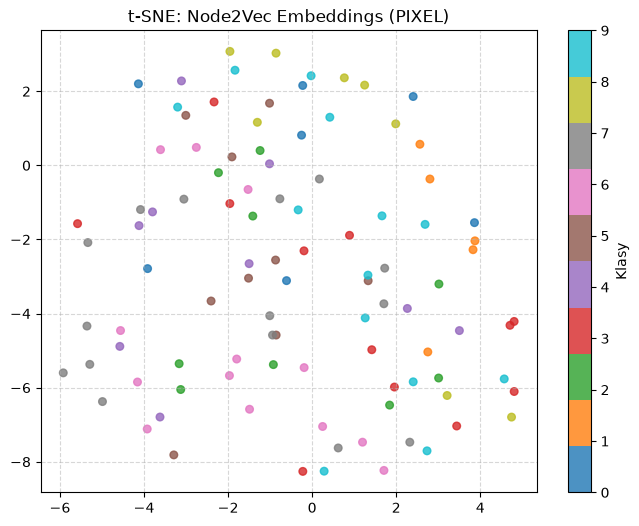


--- Analiza nienadzorowana dla: Node2Vec - PATCH ---
Silhouette Score: -0.001
Adjusted Rand Index: -0.012


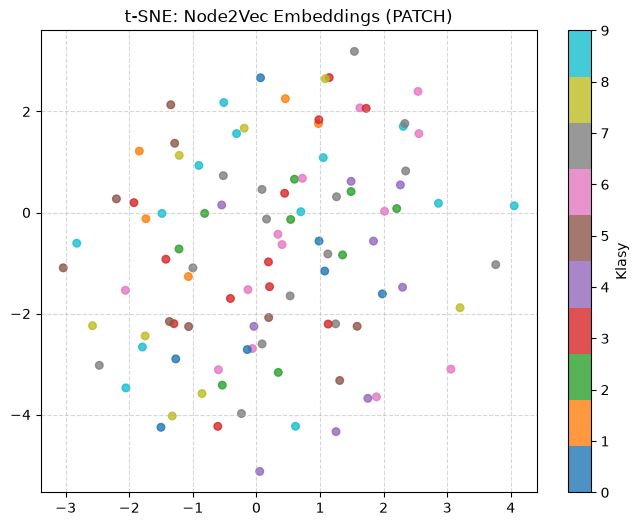


--- Analiza nienadzorowana dla: Node2Vec - SLIC ---
Silhouette Score: 0.071
Adjusted Rand Index: 0.015


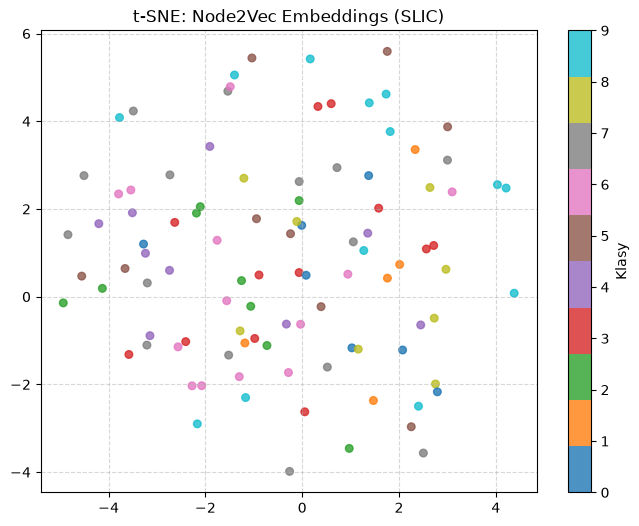

In [1]:
import os
import time
import sys
import warnings
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from joblib import Parallel, delayed
from node2vec import Node2Vec

# --- Importy dla Metod B, C oraz poprawy jakości (LAB) ---
from skimage.feature import hog
from skimage.segmentation import slic
from skimage.color import rgb2lab
from scipy.spatial.distance import cdist

# --- Importy dla klasyfikatorów i metryk ---
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

# ==========================================
# 1. FUNKCJE POMOCNICZE I PRZYGOTOWANIE DANYCH
# ==========================================

def load_cifar10_data(num_samples=None):
    print("Wczytywanie zbioru CIFAR-10...")
    transform = transforms.Compose([transforms.ToTensor()])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    
    if num_samples:
        indices = np.random.choice(len(trainset), num_samples, replace=False)
        subset = torch.utils.data.Subset(trainset, indices)
        return subset
    return trainset

# ==========================================
# 2. EKSTRAKCJA CECH (ZAAWANSOWANE METODY GRAFOWE)
# ==========================================

# Metoda A: Graf Pikselowy (Przestrzeń LAB)
def build_pixel_graph(image_array, sigma=15.0, connectivity=8):
    # POPRAWKA 1: Transformacja do LAB dla ludzkiej percepcji dystansu
    lab_image = rgb2lab(image_array)
    H, W, C = lab_image.shape
    G = nx.Graph()
    
    # Dodawanie węzłów z cechami LAB
    for i in range(H):
        for j in range(W):
            G.add_node(i * W + j, pos=(i, j), features=lab_image[i, j])

    # Dodawanie krawędzi
    for i in range(H):
        for j in range(W):
            current_node = i * W + j
            current_color = lab_image[i, j]
            
            if connectivity == 8:
                neighbors = [(i-1, j-1), (i-1, j), (i-1, j+1), (i, j-1), (i, j+1), (i+1, j-1), (i+1, j), (i+1, j+1)]
            else:
                neighbors = [(i-1, j), (i, j-1), (i, j+1), (i+1, j)]

            for ni, nj in neighbors:
                if 0 <= ni < H and 0 <= nj < W:
                    neighbor_node = ni * W + nj
                    if current_node < neighbor_node:
                        # POPRAWKA 2: Dystans liczony w LAB z większą, dopasowaną sigmą
                        dist_sq = np.sum((current_color - lab_image[ni, nj]) ** 2)
                        weight = np.exp(-dist_sq / (2 * (sigma ** 2)))
                        G.add_edge(current_node, neighbor_node, weight=weight)
    return G

# Metoda B: Graf oparty na patchach (Hybrydowy, Overlapping)
def build_patch_graph(image_array, patch_size=4, stride=2, k_neighbors=5, sigma=1.0):
    H, W, C = image_array.shape
    G = nx.Graph()
    
    patches = []
    features_for_knn = []
    idx = 0
    
    # POPRAWKA 3: Nakładające się patche (Overlapping) z użyciem stride
    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patch = image_array[i:i+patch_size, j:j+patch_size, :]
            patches.append(patch.flatten())
            
            # POPRAWKA 4: Lepsze deskryptory (Średnia + Odchylenie Standardowe)
            feat = np.concatenate([patch.mean(axis=(0,1)), patch.std(axis=(0,1))])
            features_for_knn.append(feat)
            
            G.add_node(idx, pos=(i, j), features=feat)
            idx += 1
            
    patches = np.array(patches)
    features_for_knn = np.array(features_for_knn)
    
    grid_H = (H - patch_size) // stride + 1
    grid_W = (W - patch_size) // stride + 1
    
    # POPRAWKA 5: Połączenie krawędzi przestrzennych ORAZ k-NN w jednym grafie
    # 1. Krawędzie przestrzenne (na siatce stride)
    for i in range(grid_H):
        for j in range(grid_W):
            curr = i * grid_W + j
            neighbors = [(i-1, j), (i+1, j), (i, j-1), (i, j+1)]
            for ni, nj in neighbors:
                if 0 <= ni < grid_H and 0 <= nj < grid_W:
                    neigh = ni * grid_W + nj
                    if curr < neigh:
                        dist_sq = np.sum((patches[curr] - patches[neigh]) ** 2)
                        weight = np.exp(-dist_sq / (2 * (sigma ** 2)))
                        G.add_edge(curr, neigh, weight=weight)
                        
    # 2. Krawędzie k-NN oparte na deskryptorach (Mean + Std)
    dist_matrix = cdist(features_for_knn, features_for_knn, metric='sqeuclidean')
    for i in range(len(patches)):
        nearest_indices = np.argsort(dist_matrix[i])[1:k_neighbors+1]
        for j in nearest_indices:
            if not G.has_edge(i, j):
                weight = np.exp(-dist_matrix[i, j] / (2 * (sigma ** 2)))
                G.add_edge(i, j, weight=weight)
                
    return G

# Metoda C: Graf hybrydowy (Superpiksele SLIC z wagami granic)
def build_slic_graph(image_array, n_segments=50, compactness=10, sigma=0.1):
    labels = slic(image_array, n_segments=n_segments, compactness=compactness, start_label=0, channel_axis=-1)
    unique_labels = np.unique(labels)
    G = nx.Graph()
    
    # POPRAWKA 6: Obliczanie długości granic między superpikselami
    edges_info = {}
    H, W = labels.shape
    for r in range(H):
        for c in range(W):
            lbl = labels[r, c]
            if c < W - 1 and labels[r, c+1] != lbl:
                pair = tuple(sorted([lbl, labels[r, c+1]]))
                edges_info[pair] = edges_info.get(pair, 0) + 1
            if r < H - 1 and labels[r+1, c] != lbl:
                pair = tuple(sorted([lbl, labels[r+1, c]]))
                edges_info[pair] = edges_info.get(pair, 0) + 1
                
    max_boundary = max(edges_info.values()) if edges_info else 1

    # Dodawanie węzłów z bogatymi cechami (Średnia + Std) i rozmiarem
    for lbl in unique_labels:
        mask = (labels == lbl)
        size = np.sum(mask) # Ilość pikseli w superpikselu
        mean_col = image_array[mask].mean(axis=0)
        std_col = image_array[mask].std(axis=0)
        features = np.concatenate([mean_col, std_col])
        # Zapisujemy cechy do późniejszej fuzji i rozmiar do agregacji ważonej
        G.add_node(lbl, features=features, size=size)
        
    # Tworzenie krawędzi uwzględniających długość granicy
    for (u, v), bound_len in edges_info.items():
        dist_sq = np.sum((G.nodes[u]['features'][:3] - G.nodes[v]['features'][:3]) ** 2)
        geom_weight = bound_len / max_boundary # Im dłuższa granica stykowa, tym silniejsze powiązanie
        color_weight = np.exp(-dist_sq / (2 * (sigma ** 2)))
        G.add_edge(u, v, weight=geom_weight * color_weight)
                    
    return G

# ==========================================
# 3. GENEROWANIE I FUZJA EMBEDDINGÓW
# ==========================================

def generate_node2vec_embeddings(graph, dimensions=32, walk_length=30, num_walks=20, p=1.0, q=0.5):
    # POPRAWKA 7: Wydłużone spacery i zmienione parametry p i q dla lepszej eksploracji
    n2v_obj = Node2Vec(graph, dimensions=dimensions, walk_length=walk_length, 
                       num_walks=num_walks, p=p, q=q, workers=1, quiet=True)
    model = n2v_obj.fit(window=5, min_count=1, batch_words=4)
    node_embeddings = [model.wv[str(node)] for node in sorted(graph.nodes())]
    return np.array(node_embeddings)

def aggregate_embeddings(graph, node_embeddings, method='mean', image_shape=None):
    if len(node_embeddings) == 0:
        return np.zeros(32)
        
    # POPRAWKA 8: Fuzja cech (Feature Fusion)
    # Łączymy strukturę grafu z oryginalnymi atrybutami (np. kolorem) przed agregacją
    features = [graph.nodes[n]['features'] for n in sorted(graph.nodes())]
    combined_embeddings = np.hstack([node_embeddings, np.array(features)])

    if method == 'spatial_quadrants':
        # POPRAWKA 9: Agregacja Przestrzenna (Dzieli obraz na 4 strefy, żeby zachować układ współrzędnych)
        H, W = image_shape[:2]
        mid_h, mid_w = H // 2, W // 2
        q1, q2, q3, q4 = [], [], [], []
        
        for idx, n in enumerate(sorted(graph.nodes())):
            r, c = graph.nodes[n]['pos']
            if r < mid_h and c < mid_w: q1.append(combined_embeddings[idx])
            elif r < mid_h and c >= mid_w: q2.append(combined_embeddings[idx])
            elif r >= mid_h and c < mid_w: q3.append(combined_embeddings[idx])
            else: q4.append(combined_embeddings[idx])
            
        def safe_mean(q):
            return np.mean(q, axis=0) if len(q) > 0 else np.zeros(combined_embeddings.shape[1])
            
        return np.concatenate([safe_mean(q1), safe_mean(q2), safe_mean(q3), safe_mean(q4)])
        
    elif method == 'weighted_mean':
        # POPRAWKA 10: Agregacja Ważona Rozmiarem (Superpiksele o większej masie liczą się mocniej)
        sizes = np.array([graph.nodes[n].get('size', 1) for n in sorted(graph.nodes())])
        sizes = sizes / np.sum(sizes)
        return np.average(combined_embeddings, axis=0, weights=sizes)
        
    else:
        # Standardowa uśredniona fuzja
        return np.mean(combined_embeddings, axis=0)

def process_single_image(idx, image_np, label, params):
    try:
        t0 = time.time()
        graph_type = params.get('graph_type', 'pixel')
        
        if graph_type == 'pixel':
            graph = build_pixel_graph(image_np, sigma=params['sigma'], connectivity=params['connectivity'])
        elif graph_type == 'patch':
            graph = build_patch_graph(image_np, patch_size=params['patch_size'], stride=params['stride'],
                                      k_neighbors=params['k_neighbors'], sigma=params['sigma'])
        elif graph_type == 'slic':
            graph = build_slic_graph(image_np, n_segments=params['n_segments'], 
                                     compactness=params['compactness'], sigma=params['sigma'])
        else:
            raise ValueError(f"Nieznany typ grafu: {graph_type}")
            
        t_graph = time.time() - t0
        graph_memory = sys.getsizeof(graph) + len(graph.nodes)*100 + len(graph.edges)*100
        
        t0 = time.time()
        node_emb = generate_node2vec_embeddings(graph, dimensions=params['dim'], 
                                                walk_length=params['walk_len'], num_walks=params['num_walks'],
                                                p=params['p'], q=params['q'])
        t_n2v = time.time() - t0
        
        # Agregacja zmieniona na nową wersję z obsługą fuzji i geometrii
        img_emb = aggregate_embeddings(graph, node_emb, method=params['pooling'], image_shape=image_np.shape)
        
        return idx, np.asarray(img_emb, dtype=np.float32), int(label), (float(t_graph), float(t_n2v)), int(graph_memory)
    except Exception as e:
        import traceback
        print(f"Błąd przetwarzania obrazu {idx} ({graph_type}): {e}")
        return None

# ==========================================
# 4. BASELINES
# ==========================================

def extract_baselines(image_tensor):
    image_np = image_tensor.permute(1, 2, 0).numpy()
    flat_features = image_np.flatten()
    rgb_mean = np.mean(image_np, axis=(0, 1))
    hog_features = hog(image_np, orientations=8, pixels_per_cell=(8, 8), 
                       cells_per_block=(2, 2), channel_axis=-1, feature_vector=True)
    return flat_features, rgb_mean, hog_features

# ==========================================
# 5. MODUŁY BADAWCZE (EWALUACJA)
# ==========================================

def evaluate_classifiers_cv(X, y, feature_name="Node2Vec"):
    print(f"\n--- Ocena predykcyjna (5-Fold CV) dla: {feature_name} ---")
    models = {
        'LogReg': LogisticRegression(max_iter=1000),
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM (RBF)': SVC(kernel='rbf', random_state=42)
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for name, clf in models.items():
        scores = cross_validate(clf, X, y, cv=cv, scoring=('accuracy', 'f1_macro'))
        acc_mean = np.mean(scores['test_accuracy'])
        f1_mean = np.mean(scores['test_f1_macro'])
        print(f"[{name}] Accuracy: {acc_mean:.3f} | F1-Macro: {f1_mean:.3f}")

def evaluate_unsupervised(X, y, feature_name="Node2Vec"):
    print(f"\n--- Analiza nienadzorowana dla: {feature_name} ---")
    kmeans = KMeans(n_clusters=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    
    if len(np.unique(cluster_labels)) > 1:
        sil_score = silhouette_score(X, cluster_labels)
        ari_score = adjusted_rand_score(y, cluster_labels)
        print(f"Silhouette Score: {sil_score:.3f}")
        print(f"Adjusted Rand Index: {ari_score:.3f}")

def visualize_latent_space(X, y, title="Przestrzeń Cech"):
    plt.figure(figsize=(8, 6))
    if HAS_UMAP:
        reducer = umap.UMAP(random_state=42)
        X_reduced = reducer.fit_transform(X)
        plt.title(f"UMAP: {title}")
    else:
        perplexity = min(30, max(5, len(X) // 3))
        reducer = TSNE(n_components=2, perplexity=perplexity, random_state=42)
        X_reduced = reducer.fit_transform(X)
        plt.title(f"t-SNE: {title}")
        
    scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='tab10', alpha=0.8, s=30)
    plt.colorbar(scatter, ticks=range(10), label='Klasy')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# ==========================================
# GŁÓWNA PĘTLA WYKONAWCZA
# ==========================================
if __name__ == "__main__":
    import torch
    
    NUM_SAMPLES = 100 
    dataset = load_cifar10_data(num_samples=NUM_SAMPLES)
    methods_to_test = ['pixel', 'patch', 'slic']
    results_dict = {}
    
    for graph_type in methods_to_test:
        print(f"\n{'='*60}")
        print(f"ROZPOCZĘCIE PRZETWARZANIA DLA METODY: {graph_type.upper()}")
        print(f"{'='*60}")
        
        # Baza parametrów ze zwiększonymi parametrami Node2Vec (Poprawka 7)
        PARAMS = {
            'graph_type': graph_type,
            'connectivity': 8, 
            'patch_size': 4,
            'stride': 2,        # Nowy parametr dla nakładających się patchów
            'k_neighbors': 5,
            'n_segments': 50,
            'compactness': 10.0,
            'sigma': 0.1,
            'dim': 32, 
            'walk_len': 30,     # Wydłużone z 10
            'num_walks': 20,    # Wydłużone z 10
            'p': 1.0,           
            'q': 0.5,           # Faworyzuje lokalną eksplorację grafu obrazu (BFS)
        }
        
        # Dynamiczne ustawienia dla poszczególnych rodzajów grafu
        if graph_type == 'pixel':
            PARAMS['pooling'] = 'spatial_quadrants' # Poprawka 9
            PARAMS['sigma'] = 15.0                  # Przestrzeń LAB ma odległości w skali 0-100
            g_desc = "pixel_lab_spatial"
        elif graph_type == 'patch':
            PARAMS['pooling'] = 'mean'
            PARAMS['sigma'] = 1.0
            g_desc = f"patch_overlap_{PARAMS['patch_size']}x{PARAMS['patch_size']}_stride{PARAMS['stride']}"
        elif graph_type == 'slic':
            PARAMS['pooling'] = 'weighted_mean'     # Poprawka 10
            PARAMS['sigma'] = 0.1
            g_desc = f"slic_bound_weighted_{PARAMS['n_segments']}"
            
        embeddings_file = f'n2v_embeddings_{g_desc}_N{NUM_SAMPLES}.npy'
        labels_file = f'labels_{g_desc}_N{NUM_SAMPLES}.npy'
        
        if os.path.exists(embeddings_file) and os.path.exists(labels_file):
            print(f"Wczytywanie z dysku: {embeddings_file}")
            X_n2v = np.load(embeddings_file)
            y = np.load(labels_file)
        else:
            print(f"Rozpoczęto ekstrakcję cech ({NUM_SAMPLES} obrazów)...")
            results = Parallel(n_jobs=-1, verbose=5)(
                delayed(process_single_image)(
                    i, dataset[i][0].permute(1, 2, 0).numpy(), int(dataset[i][1]), PARAMS
                ) for i in range(NUM_SAMPLES)
            )
            results = [res for res in results if res is not None]
            
            X_n2v = np.array([res[1] for res in results])
            y = np.array([res[2] for res in results])
            times = [res[3] for res in results]
            
            np.save(embeddings_file, X_n2v)
            np.save(labels_file, y)
            
            avg_t_graph = np.mean([t[0] for t in times])
            avg_t_n2v = np.mean([t[1] for t in times])
            print(f"Średni czas grafu: {avg_t_graph:.4f} s | Czas N2V: {avg_t_n2v:.4f} s")

        results_dict[graph_type] = {'X': X_n2v, 'y': y}

    # --- Liniowe Baselines ---
    baselines = [extract_baselines(dataset[i][0]) for i in range(NUM_SAMPLES)]
    y_baselines = np.array([int(dataset[i][1]) for i in range(NUM_SAMPLES)])
    X_rgb = np.array([b[1] for b in baselines])
    X_hog = np.array([b[2] for b in baselines])

    # --- Faza Predykcyjna ---
    print("\n========================================================")
    print("FAZA PREDYKCYJNA - ZBIORCZE PORÓWNANIE PO POPRAWKACH")
    print("========================================================")
    for g_type in methods_to_test:
        evaluate_classifiers_cv(results_dict[g_type]['X'], results_dict[g_type]['y'], feature_name=f"Node2Vec - {g_type.upper()}")
        
    evaluate_classifiers_cv(X_rgb, y_baselines, feature_name="Baseline (RGB Mean)")
    evaluate_classifiers_cv(X_hog, y_baselines, feature_name="Baseline (HOG)")
    
    # --- Faza Nienadzorowana ---
    print("\n========================================================")
    print("FAZA NIENADZOROWANA")
    print("========================================================")
    for g_type in methods_to_test:
        evaluate_unsupervised(results_dict[g_type]['X'], results_dict[g_type]['y'], feature_name=f"Node2Vec - {g_type.upper()}")
        visualize_latent_space(results_dict[g_type]['X'], results_dict[g_type]['y'], title=f"Node2Vec Embeddings ({g_type.upper()})")